In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")

import sys
from pathlib import Path

project_root = Path.cwd().parents[1]
sys.path.append(str(project_root))

import aymansigmri as asm

In [2]:
zte_radial_kspace, zte_radial_coords = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=0, undersampling_factor=1)

kspace_cart_coils = asm.gridding_operator(kspace_data=zte_radial_kspace, coord=zte_radial_coords)

kspace_test = kspace_cart_coils[0]

In [3]:
def onecoil_hankel(kspace, w):
    y = 0
    x = 0
    N_x = kspace.shape[0] - w + 1 
    N_y = kspace.shape[1] - w + 1
    data_matrix = np.empty((w*w,N_x*N_y),dtype=np.complex64)
    col_index = 0
    for i in range(N_y):        
        for j in range(N_x):    
            mat = kspace[x:x+w, y:y+w]
            col = mat.reshape(-1)
            data_matrix[:, col_index] = col
            x += 1
            col_index += 1
        x = 0
        y += 1
    return(data_matrix)

In [4]:
def onecoil_hankel_H(data_matrix, Nx, Ny, w):
    
    n_win_x = Nx - w + 1
    n_win_y = Ny - w + 1
    
    transposed = data_matrix.T

    print(f'{data_matrix.shape=} {transposed.shape=} {len(transposed)=}')
    
    windows = []
    for j in range(len(transposed)):
        window = transposed[j].reshape(w, w)
        windows.append(window)
    windows_full = np.array(windows)


    recon = np.zeros((Nx, Ny), dtype = np.complex64)
    for index, win in enumerate(windows_full):
        i = (index % n_win_y)
        j = (index // n_win_y)
        recon[i:i+w, j:j+w] = win
    
    return recon

In [5]:
data = onecoil_hankel(kspace_test, 5)

data_matrix.shape=(25, 63504) transposed.shape=(63504, 25) len(transposed)=63504


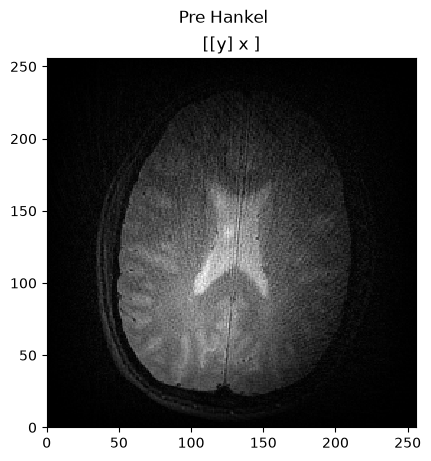

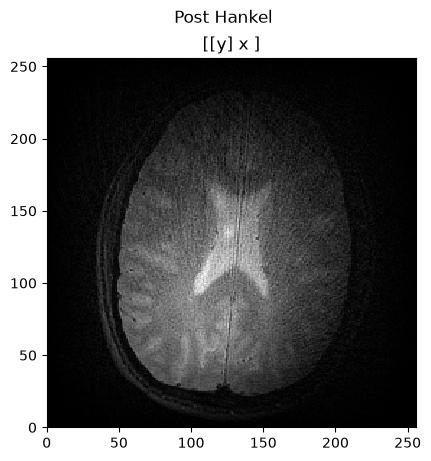

In [6]:

kspace_test2 = onecoil_hankel_H(data,256,256,5)
im = sp.ifft(kspace_test)

pl.ImagePlot(im, title='Pre Hankel')



im2 = sp.ifft(kspace_test2)

pl.ImagePlot(im2, title='Post Hankel')


In [7]:
n_coils = kspace_cart_coils.shape[0]
def hankel(kspace, w):
    x = 0
    y = 0
    c = 0
    N_x = kspace.shape[1] - w + 1 
    N_y = kspace.shape[2] - w + 1
    N_c = kspace.shape[0]
    data_matrix = []
    for k in range(N_c):
        onecoil_matrix = np.empty((w*w,N_x* N_y),dtype=np.complex64)
        col_index = 0
        for i in range(N_y):        
            for j in range(N_x):    
                mat = kspace[c,x:x+w, y:y+w]
                col = mat.T.reshape(-1)
                onecoil_matrix[:, col_index] = col
                x += 1
                col_index += 1
            x = 0
            y += 1
        data_matrix.append(onecoil_matrix)
        y = 0
        c += 1
    return(np.vstack(data_matrix), N_c, N_x, N_y)

data, n_coils, N_x, N_y = hankel(kspace_cart_coils, n_coils)

In [8]:
def hankel_H(data_matrix, n_coils, Nx, Ny, w=3):
    kspace = []
    split_arr = np.array(np.split(data_matrix, n_coils))

    n_win_x = Nx - w + 1
    n_win_y = Ny - w + 1

    for k in range(len(split_arr)):
        #n_windows = split_arr.shape[1]

        singlecol = split_arr[k]
        transposed = singlecol.T
        windows = []
        for j in range(len(transposed)):
            window = transposed[j].reshape(w,w)
            windows.append(window)
        windows_full = np.array(windows)
            

        
        recon = np.zeros((Nx, Ny), dtype=np.complex64)

        for index, win in enumerate(windows_full): 
            i = (index // n_win_y)
            j = (index % n_win_y)
            recon[i:i+w, j:j+w] = win
        kspace.append(recon.T)
    return(np.array(kspace))

kspace_recon = hankel_H(data, kspace_cart_coils.shape[0], kspace_cart_coils.shape[1], kspace_cart_coils.shape[2], w=12)

In [9]:
def hankel_H_averaged(data_matrix, n_coils, Nx, Ny, w=3):
    kspace = []
    split_arr = np.array(np.split(data_matrix, n_coils))

    n_win_x = Nx - w + 1
    n_win_y = Ny - w + 1

    for k in range(len(split_arr)):
        singlecol = split_arr[k]
        transposed = singlecol.T
        windows = []
        for j in range(len(transposed)):
            window = transposed[j].reshape(w,w)
            windows.append(window)
        windows_full = np.array(windows)
        
        recon = np.zeros((Nx, Ny), dtype=np.complex64)
        counts = np.zeros((Nx, Ny), dtype=np.float32)

        for index, win in enumerate(windows_full): 
            i = (index // n_win_y)
            j = (index % n_win_y)
            recon[i:i+w, j:j+w] += win
            counts[i:i+w, j:j+w] += 1

        recon = recon / counts
        kspace.append(recon.T)
    return np.array(kspace)


kspace_recon = hankel_H_averaged(data, kspace_cart_coils.shape[0], kspace_cart_coils.shape[1], kspace_cart_coils.shape[2], w=12)

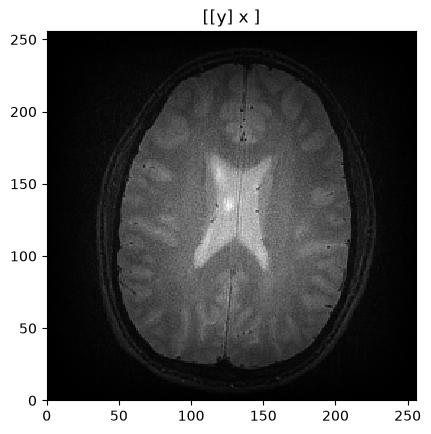

In [10]:
grid = sp.ifft(kspace_recon)

img_rss = np.sum(np.abs(grid)**2, axis=0)**0.5

pl.ImagePlot(img_rss)

## Test on a Random Dataset

In [11]:
import numpy as np

ncoils = 5
nx, ny = 300, 300
data = np.array(np.random.randn(ncoils, nx, ny) + 1j * np.random.randn(ncoils, nx, ny))
data = np.arange(1, 5 * 300 * 300 + 1).reshape(5, 300, 300)

In [53]:
hankel, coils, x, y = asm.hankel(kspace = data, w=5)

data_H = asm.hankel_H(data_matrix = hankel, n_coils=ncoils, Nx = 300, Ny = 300, w = 5)